# Loading Dataset | Handling Missing Values | Visualizations using Matplotlib/Pandas/Seaborn

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = sns.load_dataset("taxis")

In [2]:
df

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[ns]
 1   dropoff          6433 non-null   datetime64[ns]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   object        
 9   payment          6389 non-null   object        
 10  pickup_zone      6407 non-null   object        
 11  dropoff_zone     6388 non-null   object        
 12  pickup_borough   6407 non-null   object        
 13  dropoff_borough  6388 non-null   object        
dtypes: datetime64[ns](2), float64(5), int64(

In [20]:
#Impute missing values & Remove duplicates
df.isnull().sum()

pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64

In [6]:
df.describe()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total
count,6433,6433,6433.000000,6433.000000,6433.000000,6433.00000,6433.000000,6433.000000
mean,2019-03-16 08:31:28.514223616,2019-03-16 08:45:49.491217408,1.539251,3.024617,13.091073,1.97922,0.325273,18.517794
min,2019-02-28 23:29:03,2019-02-28 23:32:35,0.000000,0.000000,1.000000,0.00000,0.000000,1.300000
25%,2019-03-08 15:50:34,2019-03-08 16:12:51,1.000000,0.980000,6.500000,0.00000,0.000000,10.800000
50%,2019-03-15 21:46:58,2019-03-15 22:06:44,1.000000,1.640000,9.500000,1.70000,0.000000,14.160000
75%,2019-03-23 17:41:38,2019-03-23 17:51:56,2.000000,3.210000,15.000000,2.80000,0.000000,20.300000
max,2019-03-31 23:43:45,2019-04-01 00:13:58,6.000000,36.700000,150.000000,33.20000,24.020000,174.820000
std,NaN,NaN,1.203768,3.827867,11.551804,2.44856,1.415267,13.815570


In [7]:
df.describe(include="object")

,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
count,6433,6389,6407,6388,6407,6388
unique,2,2,194,203,4,5
top,yellow,credit card,Midtown Center,Upper East Side North,Manhattan,Manhattan
freq,5451,4577,230,245,5268,5206


In [9]:
import warnings
warnings.filterwarnings('ignore')

In [12]:
numerical_columns = df.select_dtypes(include = "number").columns
print("Numerical columns : \n",numerical_columns)

non_numerical_coulmns = df.select_dtypes(include =  "object").columns
print("Non_Numerical columns : \n",non_numerical_coulmns)

df[numerical_columns] = df[numerical_columns].fillna(df[numerical_columns].mean())

Categorical_col  = df[non_numerical_coulmns].mode().iloc[0]
df[non_numerical_coulmns] = df[non_numerical_coulmns].fillna(Categorical_col)

df.dropna(inplace=True)

Numerical columns : 
 Index(['passengers', 'distance', 'fare', 'tip', 'tolls', 'total'], dtype='object')
Non_Numerical columns : 
 Index(['color', 'payment', 'pickup_zone', 'dropoff_zone', 'pickup_borough',
       'dropoff_borough'],
      dtype='object')


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[ns]
 1   dropoff          6433 non-null   datetime64[ns]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   object        
 9   payment          6433 non-null   object        
 10  pickup_zone      6433 non-null   object        
 11  dropoff_zone     6433 non-null   object        
 12  pickup_borough   6433 non-null   object        
 13  dropoff_borough  6433 non-null   object        
dtypes: datetime64[ns](2), float64(5), int64(

In [14]:
df.shape

(6433, 14)

In [15]:
df.isnull().sum()

pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64

In [16]:
df.isnull().mean()*100

pickup             0.0
dropoff            0.0
passengers         0.0
distance           0.0
fare               0.0
tip                0.0
tolls              0.0
total              0.0
color              0.0
payment            0.0
pickup_zone        0.0
dropoff_zone       0.0
pickup_borough     0.0
dropoff_borough    0.0
dtype: float64

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.drop_duplicates()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn


In [21]:
df

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn


# Visualizations using Matplotlib/Pandas Plot:

In [27]:
df["pickup"] = pd.to_datetime(df["pickup"])
df["pickup"].dtypes


dtype('<M8[ns]')

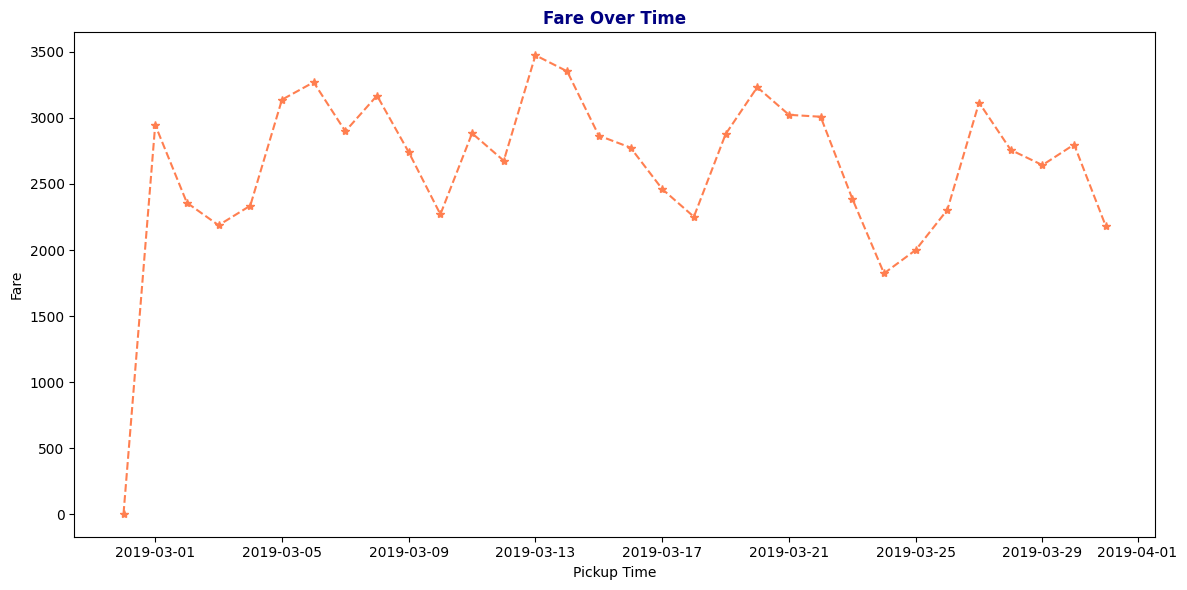

In [78]:
#Line Chart:Plot a line chart to visualize the fare over time, using the pickup timestamp as the x-axis and fare as the y-axis. Ensure the pickup column is converted to a datetime format before plotting.


pickup_fare =  df.groupby(df["pickup"].dt.date)["fare"].sum()
plt.figure(figsize=(12,6))
pickup_fare.plot(color="coral", marker="*",ls="dashed")
plt.title("Fare Over Time", fontweight="bold", color="navy")
plt.xlabel("Pickup Time", fontweight="medium")
plt.ylabel("Fare", fontweight="medium")
plt.tight_layout()
plt.show()



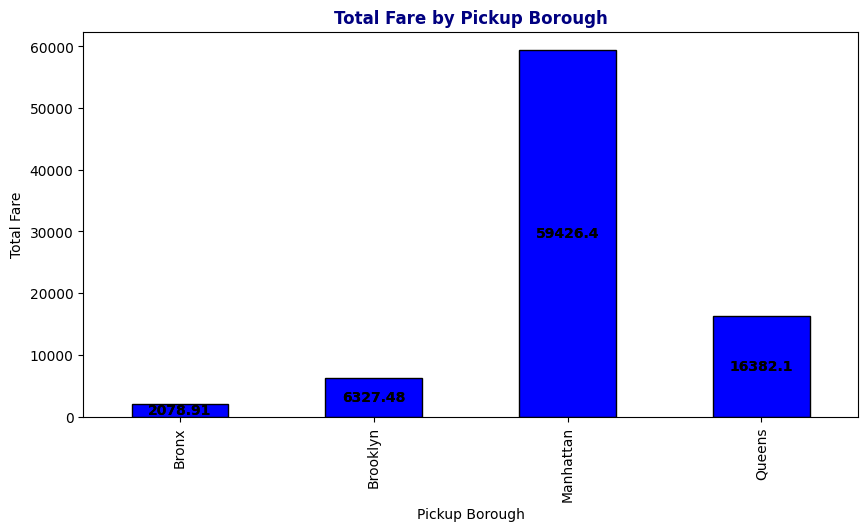

In [79]:
#Bar Chart :Create a bar chart to show the total fare for each pickup_borough. Group the data by pickup_borough and sum the fare for each group.

fare_borough = df.groupby('pickup_borough')['fare'].sum()

plt.figure(figsize=(10,5))
fare_borough.plot(kind='bar', color="cyan")
plt.title("Total Fare by Pickup Borough", fontweight="bold", color="navy")
Bar = fare_borough.plot(kind = "bar",color = "blue", edgecolor="black")

#Datalabels
for container in Bar.containers:
    Bar.bar_label(container, label_type="center", fontweight="bold")
    
plt.xlabel("Pickup Borough",fontweight="medium")
plt.ylabel("Total Fare",fontweight="medium")
plt.show()


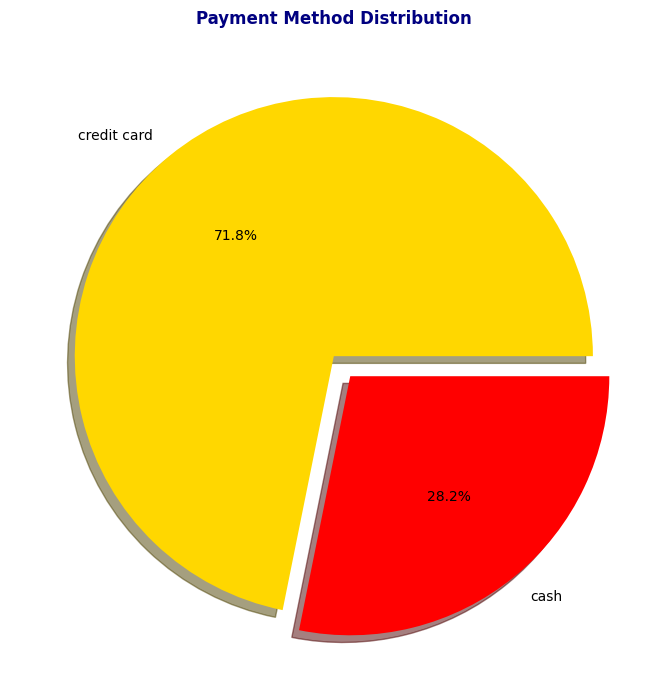

In [57]:
#Pie Chart:Plot a pie chart showing the distribution of trips based on the payment method (credit card, cash, etc.). Each slice should represent the count of trips for a specific payment method.

payment_counts = df['payment'].value_counts()

plt.figure(figsize=(8,7))

plt.pie(payment_counts,autopct='%1.1f%%',labels=payment_counts.index,explode=(0,0.1),colors=["gold","red"],shadow=True)

plt.title("Payment Method Distribution", fontweight="bold",color="navy")
plt.tight_layout()
plt.show()



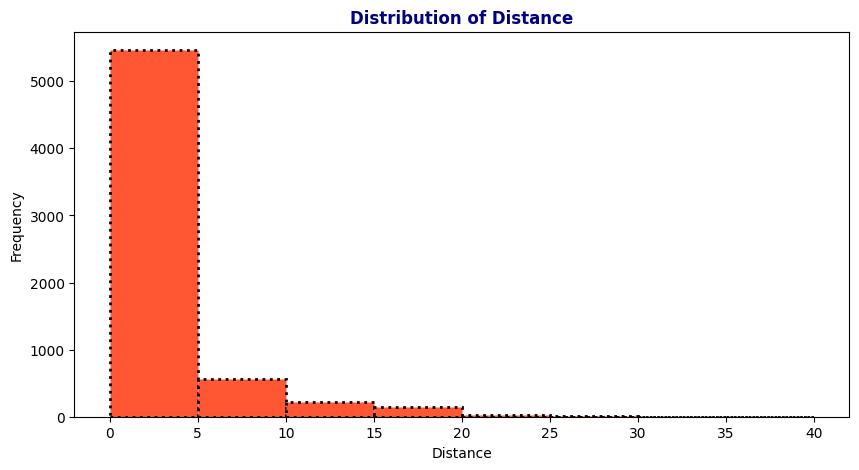

In [80]:
#Histogram:To visualize the distribution of distance. Customize the number of bins for better granularity and ensure the plot is easy to interpret.

plt.figure(figsize=(10,5))
plt.hist(df["distance"],bins=(0,5,10,15,20,25,30,35,40),color = "#FF5733",linestyle ="dotted",linewidth=2,edgecolor="black")
plt.xlabel("Distance",fontweight = "medium")
plt.ylabel("Frequency",fontweight = "medium")
plt.title("Distribution of Distance",fontweight = "bold", color="navy")
plt.show()

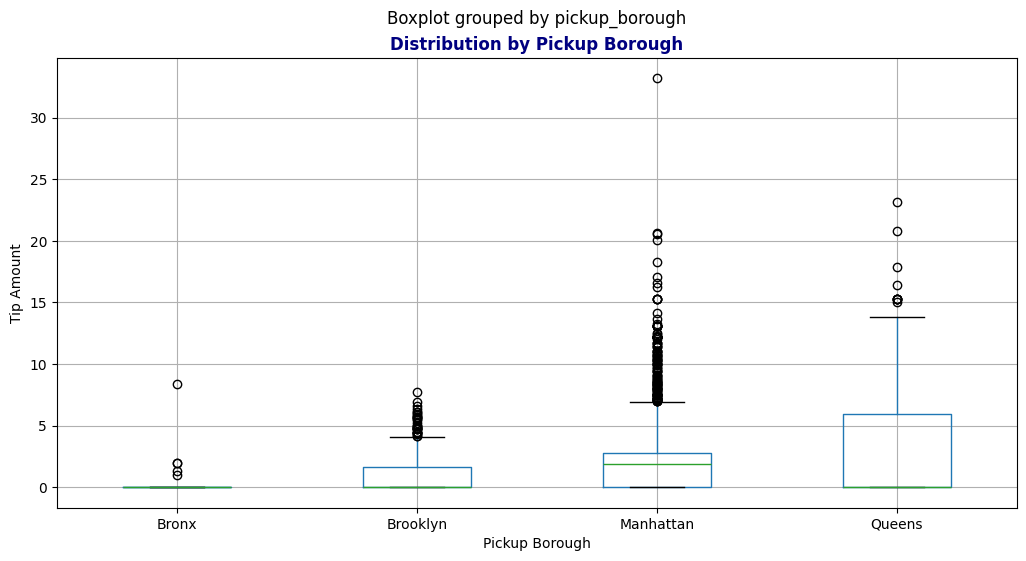

In [81]:
#Box Plot:To visualize the distribution of tip amounts for each pickup_borough. Use pickup_borough as the categorical axis and tip as the numeric axis.

df.boxplot("tip", by="pickup_borough", figsize=(12,6))
plt.title("Distribution by Pickup Borough",fontweight = "bold",color="navy")
plt.xlabel("Pickup Borough",fontweight = "medium")
plt.ylabel("Tip Amount",fontweight = "medium")
plt.show()

# Visualizations using Seaborn

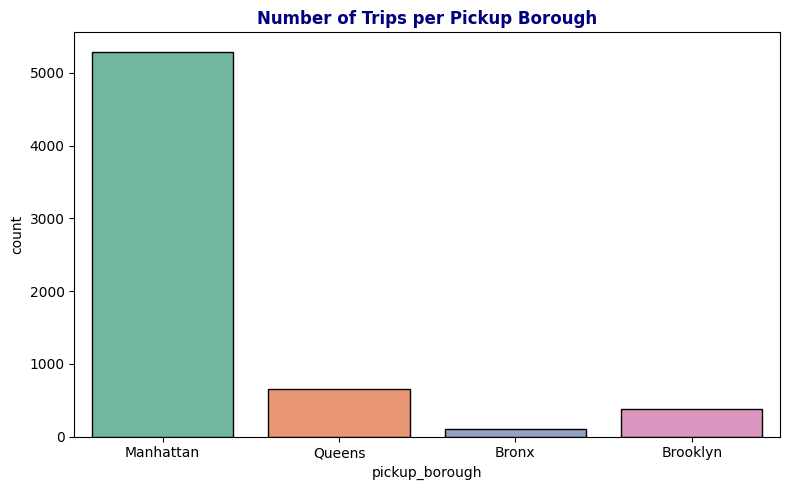

In [82]:
#Count Plot:To visualize the number of trips in each pickup_borough. The x-axis should represent the boroughs, and the y-axis should show the count of trips.

plt.figure(figsize=(8,5))

sns.countplot(x='pickup_borough',data=df, palette="Set2", edgecolor="black",)

plt.title("Number of Trips per Pickup Borough", fontweight="bold", color="navy")
plt.tight_layout()
plt.show()


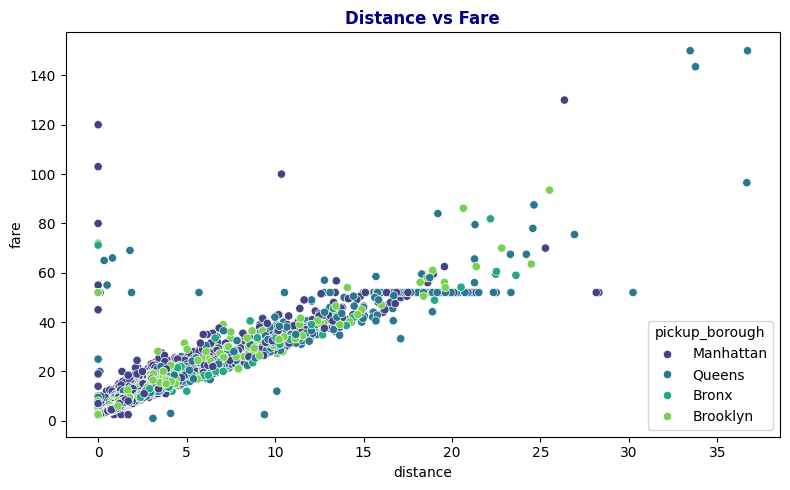

In [83]:
#Scatter Plot: To show the relationship between distance and fare. Use distance on the x-axis and fare on the y-axis to visualize any correlation. Color the points based on the pickup_borough to differentiate the trips by their respective boroughs.

plt.figure(figsize=(8,5))

sns.scatterplot(data=df,x='distance',y='fare',hue='pickup_borough',palette="viridis")

plt.title("Distance vs Fare", fontweight="bold", color="navy")

plt.tight_layout()
plt.show()

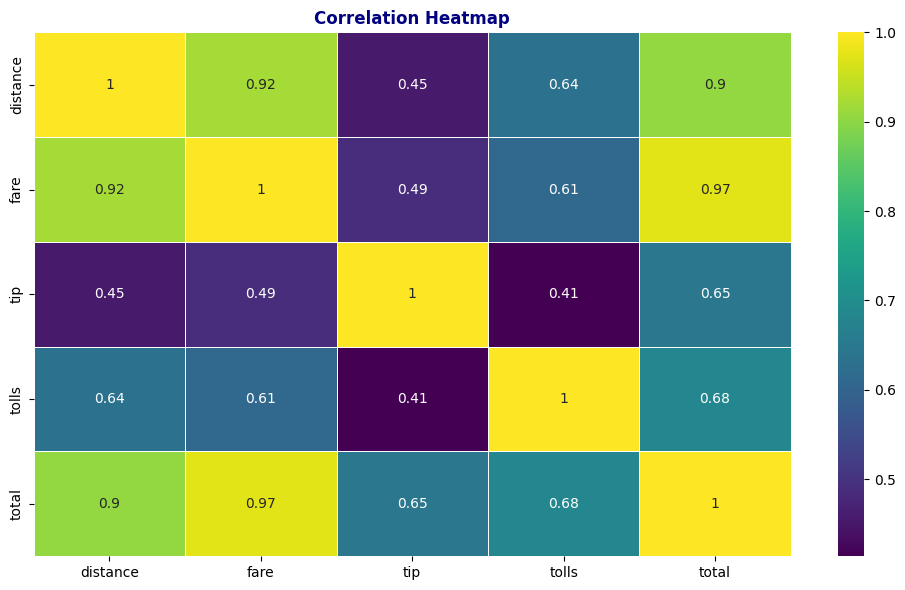

In [84]:
#Heatmap: To visualize the correlation between numerical variables such as distance, fare, tip, tolls, and total. Use a correlation matrix to highlight the relationships.


plt.figure(figsize=(10,6))

corr = df[['distance','fare','tip','tolls','total']].corr()
sns.heatmap(corr,annot=True,cmap="viridis",linewidths=0.5)
plt.title("Correlation Heatmap", fontweight="bold",color="navy")
plt.tight_layout()
plt.show()



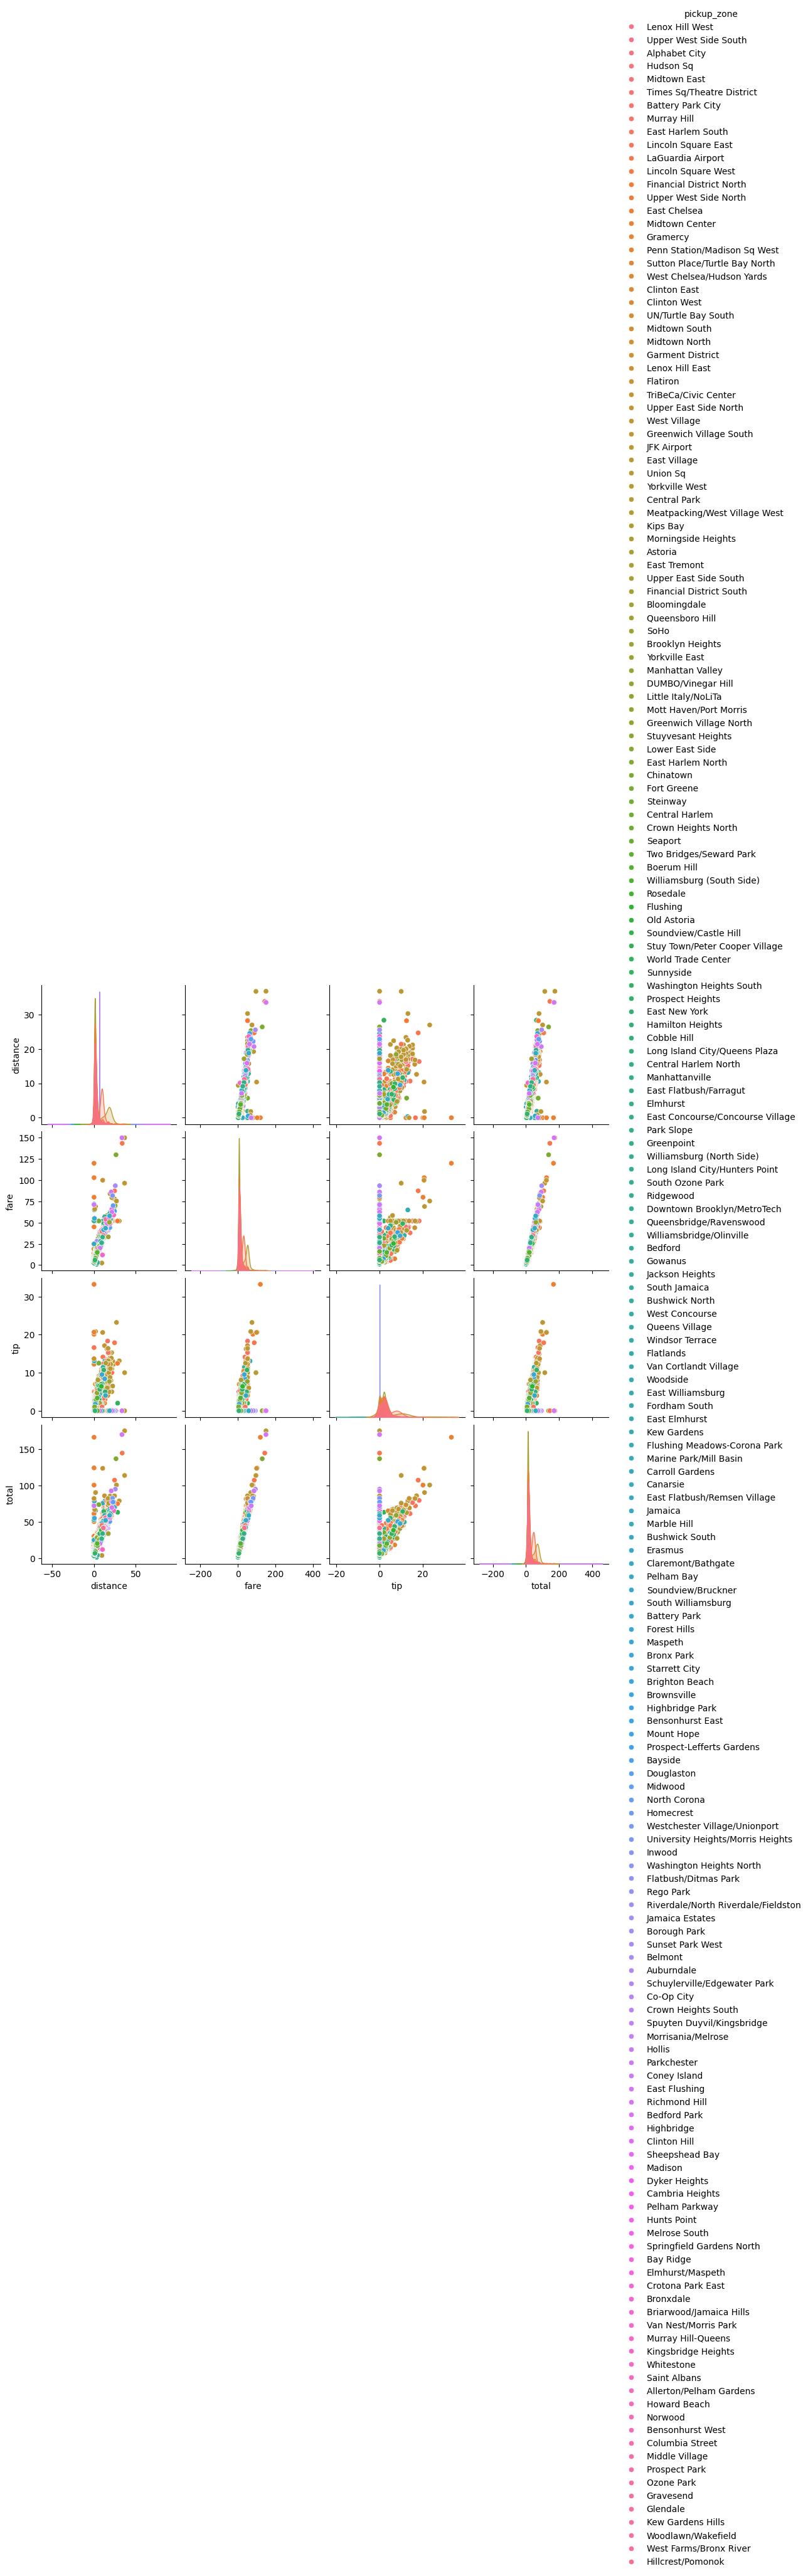

In [92]:
#Pair Plot: To visualize the pairwise relationships between distance, fare, tip, and total. Color the data points according to the pickup_zone method to compare how different zones affect these variables

pair_plot = sns.pairplot(df[['distance','fare','tip','total','pickup_zone']],hue='pickup_zone',palette="husl")
plt.show()


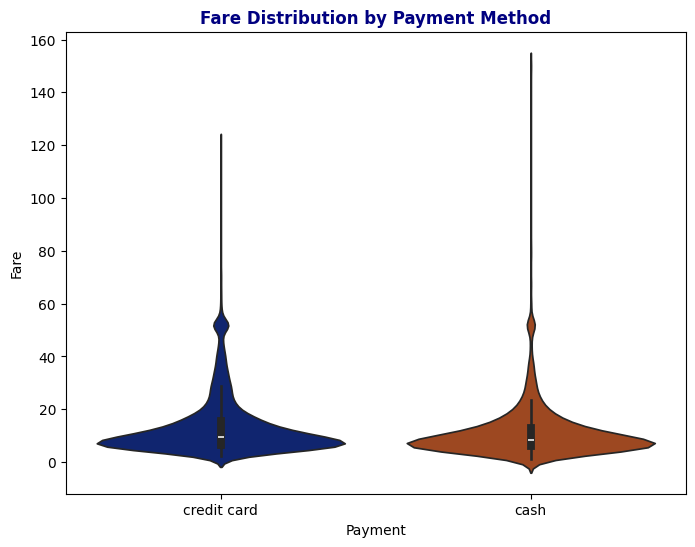

In [90]:
#Violin Plot: To show the distribution of fare for each payment method. Use the payment method as the categorical axis and fare as the numeric axis to visualize its distribution.

plt.figure(figsize=(8,6))
sns.violinplot(data=df,x='payment', y='fare',palette="dark")
plt.title("Fare Distribution by Payment Method", fontweight="bold",color="navy")
plt.xlabel("Payment",fontweight="medium")
plt.ylabel("Fare",fontweight="medium")
plt.show()

